In [152]:
import numpy as np
import pandas as pd



#Cargar las bases de datos

In [2]:
import pandas as pd

# base 2 listado de resultados de categoría minciencias

url = 'https://raw.githubusercontent.com/PatriciaFS167/UC-PAD_cuaderno_jupiter_actividad-5/main/convocatoriaa.csv'

# nrows limita la lectura a las primeras filas
minciencias = pd.read_csv(url, sep=";",encoding='latin1')
minciencias.shape

(25514, 2)

In [3]:
## base # 2 que es listado de docentes solicitados

# Corrected URL to raw CSV data on GitHub
url = 'https://raw.githubusercontent.com/PatriciaFS167/UC-PAD_cuaderno_jupiter_actividad-5/main/muestras.csv'

# nrows limita la lectura a las primeras filas
docentes = pd.read_csv(url, sep=";", encoding='latin1')
docentes.shape

(40, 1)

#Revisar las columnas de cada base

In [4]:
minciencias.columns

Index(['documento', 'tipo de investigador'], dtype='object')

In [5]:
docentes.columns

Index(['documento'], dtype='object')

In [6]:
minciencias.head()

,documento,tipo de investigador
0,610891090,Investigador Sénior (IS)
1,668365730,Investigador Asociado (I)
2,3383839,Investigador Junior (IJ)
3,30180796,Investigador Sénior (IS)
4,03464606R,Investigador Sénior (IS)


In [7]:
docentes.head()

,documento
0,52848924
1,53120854
2,1013614554
3,79800628
4,79557883


#Tipos de dato

In [8]:
# ¿Qué tipo asignó pandas a cada columna en la base miciencias?
minciencias.dtypes.head()

,0
documento,object
tipo de investigador,object


In [9]:
# ¿Qué tipo asignó pandas a cada columna en la base docentes?

docentes.dtypes.head()

,0
documento,int64


In [10]:
#Para pasar el tipo de dato de documento tipo int a object de la base docentes?

docentes['documento'] = docentes['documento'].astype(object)

docentes.dtypes.head()

,0
documento,object


In [11]:
minciencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25514 entries, 0 to 25513
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   documento             25514 non-null  object
 1   tipo de investigador  25514 non-null  object
dtypes: object(2)
memory usage: 398.8+ KB


In [12]:
docentes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   documento  40 non-null     object
dtypes: object(1)
memory usage: 452.0+ bytes


In [13]:
# Cuántos faltantes tiene cada columna
faltantes = minciencias.isna().sum()
faltantes[faltantes > 0]

faltantes = docentes.isna().sum()
faltantes[faltantes > 0]

,0


In [14]:
# Cuántas filas están repetidas por completo
minciencias.duplicated().sum()

np.int64(0)

In [15]:
docentes.duplicated().sum()

np.int64(2)

In [16]:
# Para saber cuáles son las dos filas duplicadas

docentes[docentes.duplicated(keep=False)]

,documento
12,19063801
13,19063801
24,79570878
25,79570878


In [17]:
#Eliminar las filas duplicadas

docentes = docentes.drop_duplicates()

In [18]:
#Para comprobar que las filas duplicadas se eliminaron

docentes.duplicated().sum()

np.int64(0)

In [25]:
#Cambiar el nombre de la columna "tipo de investigador"
# Para que sea más fácil de interpretar,cambiamos "tipo de investigador" por "categoria_minciencias".

minciencias = minciencias.rename(columns={"tipo de investigador": "categoria"})

minciencias.shape
minciencias.columns

Index(['documento', 'categoria'], dtype='object')

In [27]:
# Cómo están escritas realmente las categorías

minciencias['categoria'].value_counts(dropna=False)

,count
categoria,
Investigador Junior (IJ),15411
Investigador Asociado (I),5542
Investigador Sénior (IS),4437
Investigador Emérito (IE),124


In [28]:
#Seleccionar las columnas de trabajo

columnas = ["documento", "categoria"]

minciencias_categoria = minciencias[columnas]
minciencias_categoria.shape

(25514, 2)

In [80]:
#Cruzar las dos bases

#on="documento" indica que las bases se cruzan utilizando el número de documento.
# how="left" significa que conservamos todos los docentes de la Universidad y buscamos su información en la base de Minciencias
# validate='many_to_one' detiene el proceso si el documento está repetido en la base

# Convertir la columna 'documento' en docentes a tipo str para que coincida con minciencias_categoria
docentes['documento'] = docentes['documento'].astype(str)

resultado = docentes.merge(
    minciencias_categoria,
    on="documento",
    how="left",
    validate='many_to_one')

resultado.shape

(38, 2)

#Verificación de calidad

In [81]:
resultado.columns

Index(['documento', 'categoria'], dtype='object')

In [83]:
print('filas iniciales:', docentes.shape[0])
print('filas finales:', resultado.shape[0])
print('filas eliminadas:', docentes.shape[0] - resultado.shape[0])

filas iniciales: 38
filas finales: 38
filas eliminadas: 0


In [58]:
print('faltantes:', resultado.isna().sum().sum())

faltantes: 24


In [60]:
# Las filas iduplicadass siguen ahí y es lo esperado: se documentó por qué se conservan
resultado.duplicated().sum()

np.int64(0)

In [84]:
resultado.dtypes

,0
documento,object
categoria,object


#Cargar

In [124]:
# Guarda un archivo en formato CSV con título docentes reconocidos
resultado.to_csv('docentes_reconocidos.csv', index=False)

print("Archivo CVS creado exitosamente")

Archivo CVS creado exitosamente


In [93]:
# utf-8-sig hace que Excel abra bien las tildes en Windows
resultado.to_csv('docentes_reconocidos.csv', index=False, encoding='utf-8-sig')

#Comprobación sobre la tabla limpia

In [85]:
resumen = resultado.groupby("categoria")["documento"].count()
resumen

,documento
categoria,
Investigador Asociado (I),5
Investigador Junior (IJ),7
Investigador Sénior (IS),2


In [157]:
display(resultado.head(40))

,documento,categoria
0,52848924,NaN
1,53120854,NaN
2,1013614554,NaN
3,79800628,NaN
4,79557883,NaN
5,1113636417,NaN
6,80194995,Investigador Asociado (I)
7,19268144,NaN
8,19494483,NaN
9,1015433481,Investigador Junior (IJ)


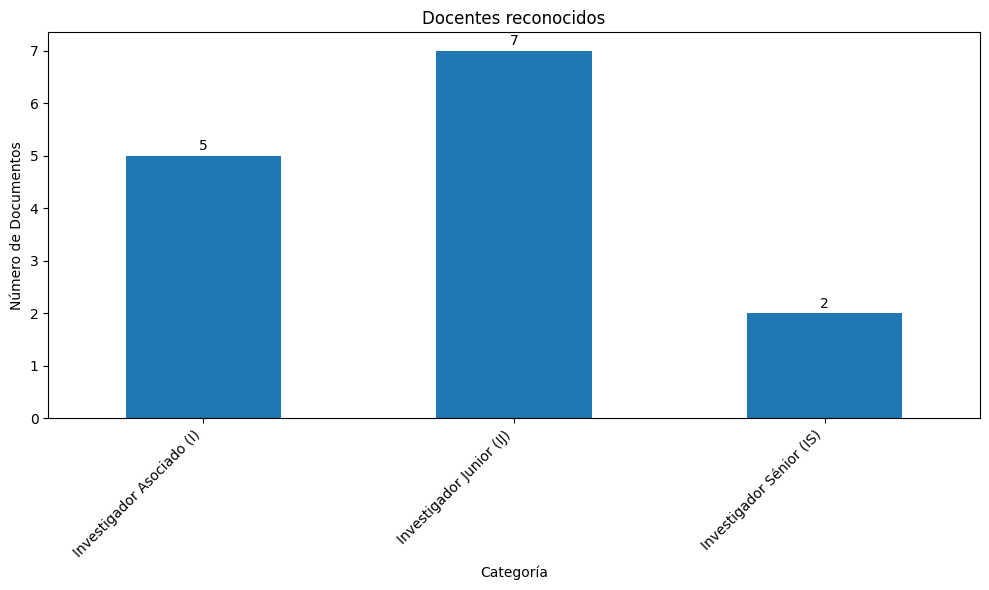

In [156]:
import matplotlib.pyplot as plt

# Para graficar categorías, es más adecuado un gráfico de barras.
# Usaremos el 'resumen' que ya calculamos.
# Aseguramos que 'resumen' sea la Serie correcta antes de graficarla.
resumen = resultado.groupby("categoria")["documento"].count()

ax = resumen.plot(kind='bar', figsize=(10, 6))
plt.title('Docentes reconocidos')
plt.xlabel('Categoría')
plt.ylabel('Número de Documentos')
plt.xticks(rotation=45, ha='right') # Rota las etiquetas del eje x para mejor legibilidad
plt.tight_layout() # Ajusta el diseño para que no se corten las etiquetas

# Añadir los números encima de cada barra
for i, v in enumerate(resumen.values):
    ax.text(i, v + 0.1, str(v), color='black', ha='center')

plt.show() # Esta función es la que genera y muestra el gráfico